In [2]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# 샘플데이터 생성 
X, _ = make_blobs(n_samples=50, centers=3, cluster_std=1.0, random_state=42)

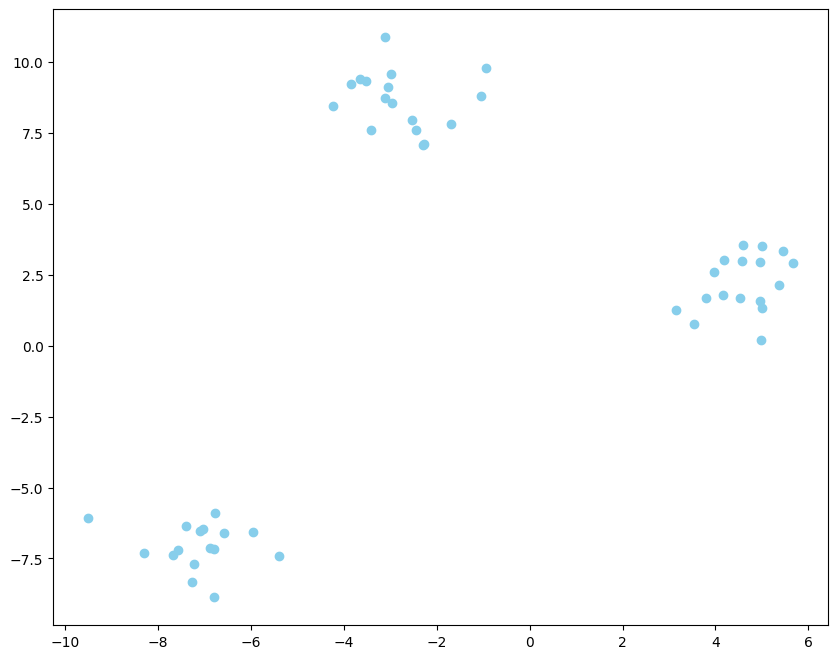

In [3]:
plt.figure(figsize=(10,8))
plt.scatter(X[:,0], X[:,1], c='skyblue')

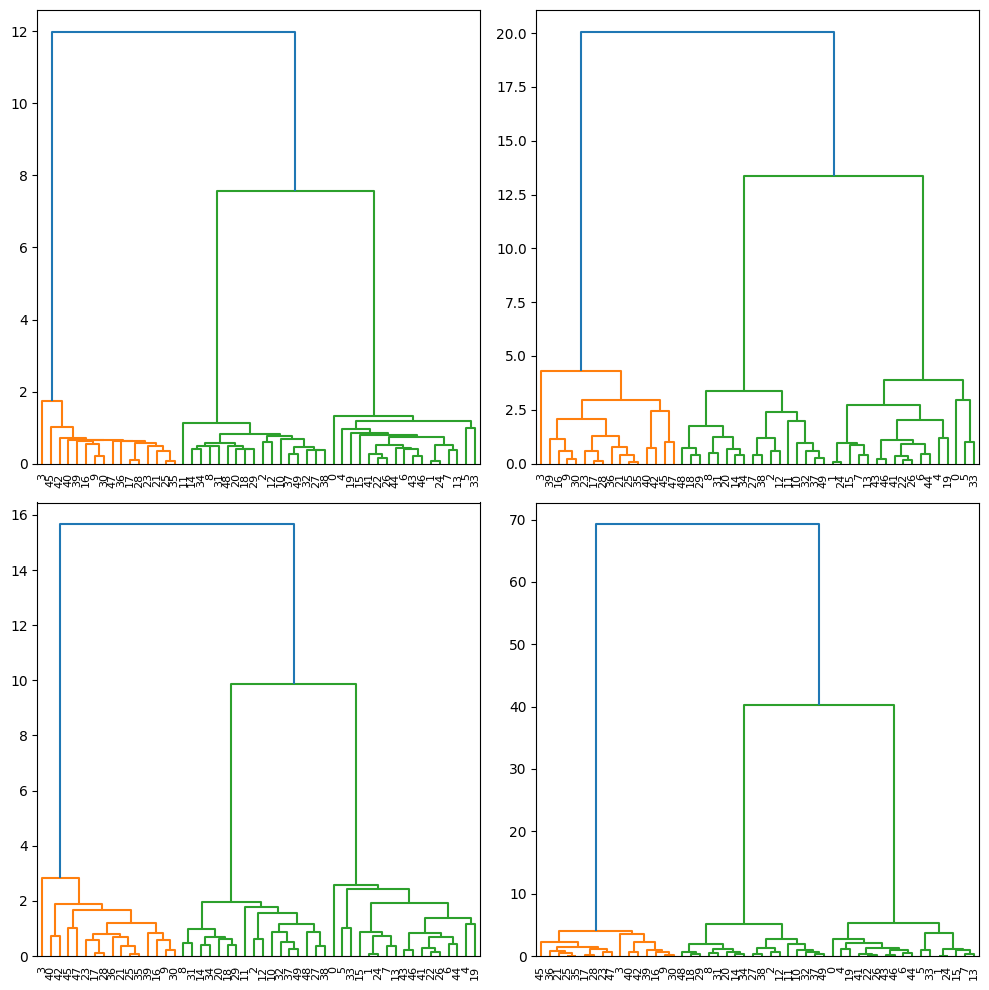

In [5]:
methods= ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(10,10))
for i, method in enumerate(methods, 1):
    plt.subplot(2,2,i)
    linked=linkage(X, method=method) # 계층적 군집 방법에 따라 계산
    dendrogram(linked)

plt.tight_layout()
plt.show()

In [7]:
## 
from sklearn.datasets import make_moons

moons_x, _ = make_moons(n_samples =300, noise=0.05, random_state=111)

In [9]:
moons_x

array([[ 9.93929765e-01,  6.42707726e-02],
       [ 8.45251538e-01,  4.33769513e-01],
       [ 9.98854288e-01, -5.15126286e-01],
       [ 1.18574945e+00, -4.79671466e-01],
       [-1.03328973e+00, -2.73453246e-02],
       [-9.90036363e-01,  1.18276604e-02],
       [ 9.30828000e-02,  1.12037427e+00],
       [ 3.69795675e-01, -1.98653962e-01],
       [ 6.73987162e-01,  6.95401896e-01],
       [ 1.72938461e+00, -2.06523061e-02],
       [ 1.41652190e+00, -3.65675478e-01],
       [ 4.79016606e-01, -3.60543198e-01],
       [-8.57353570e-01,  3.67276557e-01],
       [ 3.97787746e-01,  8.92575249e-01],
       [-8.86209986e-01,  4.55475569e-01],
       [ 2.69982108e-01, -6.75233569e-02],
       [ 5.50456915e-01, -2.64319067e-01],
       [ 6.23661386e-01,  8.46791678e-01],
       [ 7.97831879e-01,  5.89891393e-01],
       [ 9.44512162e-01, -4.88948530e-01],
       [-8.18285847e-01,  5.87659814e-01],
       [ 7.27701499e-01, -4.82730191e-01],
       [-9.51253905e-01,  3.53246220e-01],
       [ 9.

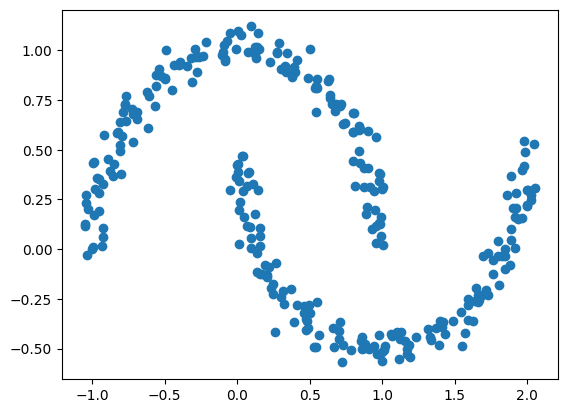

In [10]:
plt.scatter(moons_x[:,0], moons_x[:,1])

In [11]:
import pandas as pd
df = pd.read_csv('mall_customers.csv')

In [12]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [13]:
df_sp = df[['Annual Income (k$)','Spending Score (1-100)']]

In [14]:
X = df_sp.values

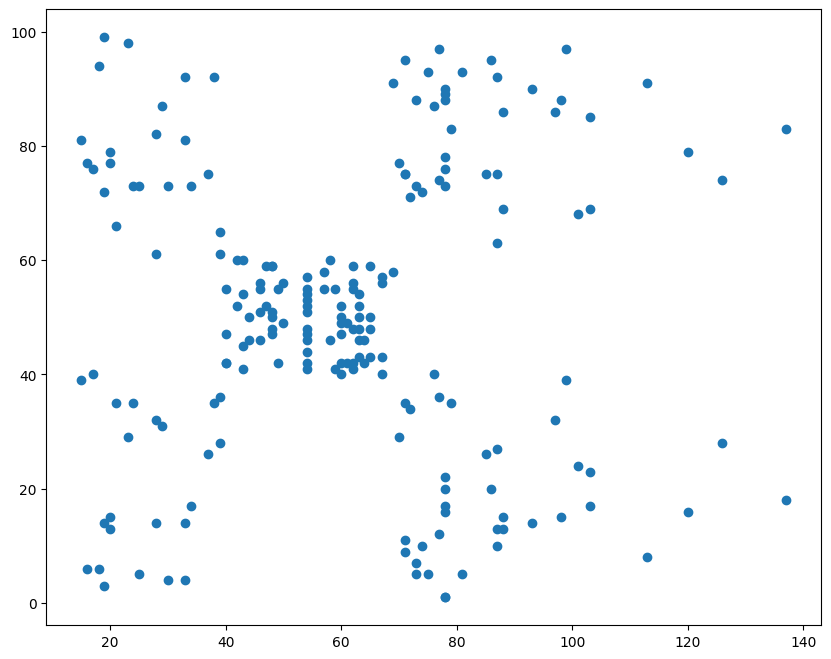

In [15]:
plt.figure(figsize=(10,8))
plt.scatter(X[:,0], X[:,1])

In [16]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [21]:
# 스케일러 불러오기
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)

In [22]:
## KMeans 클러스터링
kmeans = KMeans(n_clusters = 5, random_state=111)
kmeans_label = kmeans.fit_predict(X_scaled)

## 계층적 클러스터링
linked = linkage(X_scaled, 'ward') # 계층적 군집 방법에 따라 계산

D:\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [23]:
kmeans_label

array([1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0,
       1, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 3, 4, 0, 4, 3, 4, 3, 4,
       0, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4,
       3, 4])

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [75.0, 75.0, 85.0, 85.0],
  [65.0, 65.0, 80.0, 80.0],
  [55.0, 55.0, 72.5, 72.5],
  [45.0, 45.0, 63.75, 63.75],
  [35.0, 35.0, 54.375, 54.375],
  [12.5, 12.5, 44.6875, 44.6875],
  [105.0, 105.0, 115.0, 115.0],
  [95.0, 95.0, 110.0, 110.0],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [165.0, 165.0, 175.0, 175.0],
  [142.5, 142.5, 170.0, 170.0],
  [125.0, 125.0, 156.25, 156.25],
  [185.0, 185.0, 195.0, 195.0],
  [215.0, 215.0, 225.0, 225.0],
  [205.0, 205.0, 220.0, 220.0],
  [190.0, 190.0, 212.5, 212.5],
  [140.625, 140.625, 201.25, 201.25],
  [102.5, 102.5, 170.9375, 170.9375],
  [235.0, 235.0, 245.0, 245.0],
  [255.0, 255.0, 265.0, 265.0],
  [240.0, 240.0, 260.0, 260.0],
  [285.0, 285.0, 295.0, 295.0],
  [275.0, 275.0, 290.0, 290.0],
  [315.0, 315.0, 325.0, 325.0],
  [305.0, 305.0, 320.0, 320.0],
  [282.5, 282.5, 312.5, 312.5],
  [250.0, 250.0, 297.5, 297.5],
  [335.0, 335.0, 345.0, 345.0],
  [355.0

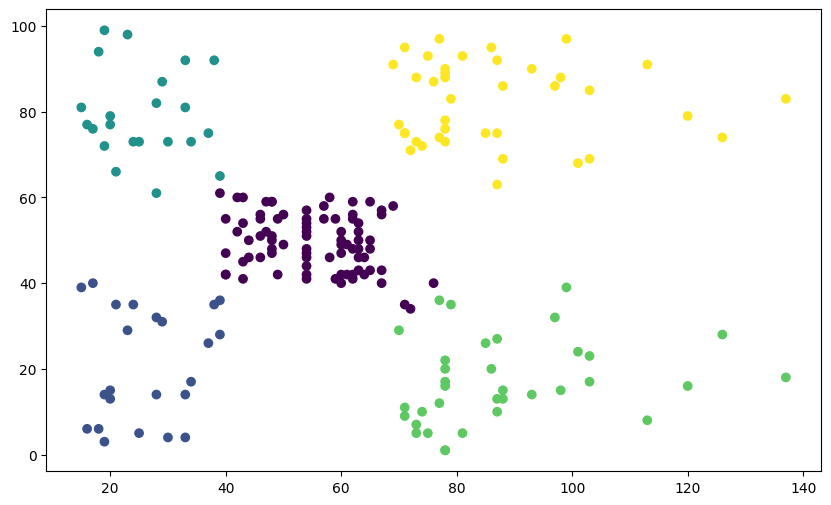

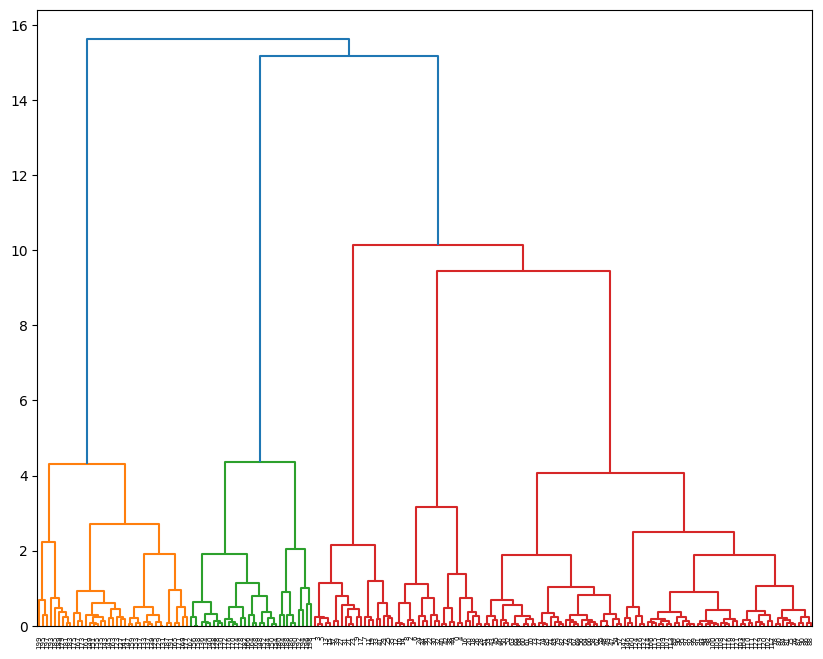

In [26]:
## 시각화로 비교를 진행하자
import numpy as np

plt.figure(figsize=(10,6))
plt.scatter(X[:,0], X[:,1], c=kmeans_label, cmap='viridis')

## 계층적 클러스터링(덴드로그램)
plt.figure(figsize=(10,8))
dendrogram(linked, labels = np.arange(len(X)))